# Experimentación y Análisis Pregunta 1 Ruido Poisson y filtrado Gaussiano adaptativo

## Importaciones

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.p1 import (
    imagen_sintetica,
    kernel_gaussiano,
    filtro_gaussiano,
    rmse,
    funcion_mapeo_sigma,
    filtro_gaussiano_adaptativo,
    x,
    y,
    mask_fondo,
    mask_cuadrado,
    mask_circulo,
    N   
)
import os
os.makedirs('results', exist_ok=True)
os.makedirs(os.path.join('results', 'p1'), exist_ok=True)

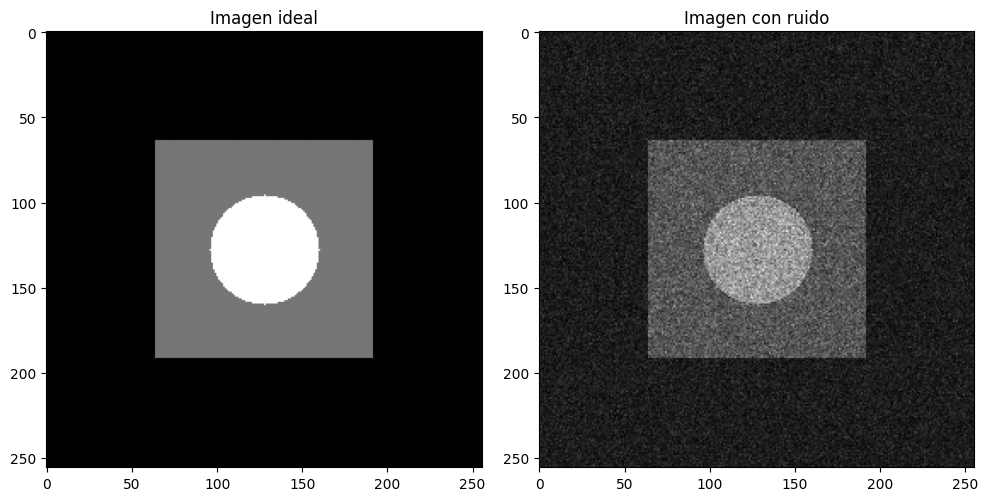

In [2]:
# verificar imagen
fig,ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(x, cmap='gray')
ax[0].set_title('Imagen ideal')
ax[1].imshow(y, cmap='gray')
ax[1].set_title('Imagen con ruido')
plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p1', 'imagen_ruido.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

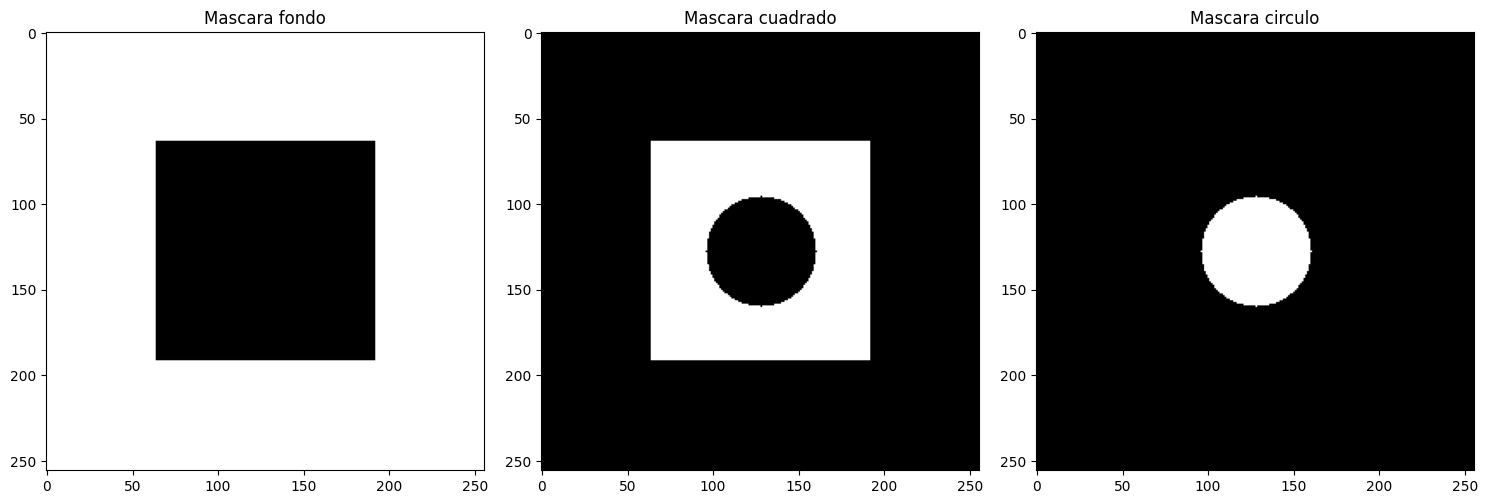

Mascara fondo y cuadrado son excluyentes: True
Mascara fondo y circulo son excluyentes: True
Mascara cuadrado y circulo son excluyentes: True


In [3]:
# vericar mascaras
fig,ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(mask_fondo, cmap='gray')
ax[0].set_title('Mascara fondo')
ax[1].imshow(mask_cuadrado, cmap='gray')
ax[1].set_title('Mascara cuadrado')
ax[2].imshow(mask_circulo, cmap='gray')
ax[2].set_title('Mascara circulo')
plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p1', 'mascaras.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()
# comprobar que las mascaras son excluyentes
print("Mascara fondo y cuadrado son excluyentes:", np.all((mask_fondo & mask_cuadrado) == 0))
print("Mascara fondo y circulo son excluyentes:", np.all((mask_fondo & mask_circulo) == 0))
print("Mascara cuadrado y circulo son excluyentes:", np.all((mask_cuadrado & mask_circulo) == 0))

## 1. Exploración valores $\sigma$ e Identificación mínimo de RMSE por regiones y global

In [4]:
# Ranfo de sigma
sigmas = np.linspace(0.0, 5.0, 51)

rmse_fondo = []
rmse_cuadrado = []
rmse_circulo = []
rmse_global = []

for sigma in sigmas:
    y_filtrada = filtro_gaussiano(y, sigma)
    rmse_fondo.append(rmse(x[mask_fondo], y_filtrada[mask_fondo]))
    rmse_cuadrado.append(rmse(x[mask_cuadrado], y_filtrada[mask_cuadrado]))
    rmse_circulo.append(rmse(x[mask_circulo], y_filtrada[mask_circulo]))
    rmse_global.append(rmse(x, y_filtrada))

# identificar el sigma que minimiza el RMSE global
idx_min_fondo = np.argmin(rmse_fondo)
idx_min_cuadrado = np.argmin(rmse_cuadrado)
idx_min_circulo = np.argmin(rmse_circulo)
idx_min_global = np.argmin(rmse_global)

sigma_min_fondo = sigmas[idx_min_fondo]
sigma_min_cuadrado = sigmas[idx_min_cuadrado]
sigma_min_circulo = sigmas[idx_min_circulo]
sigma_min_global = sigmas[idx_min_global]



## 2. Grafica $\sigma$ vs RMSE (por región y global)

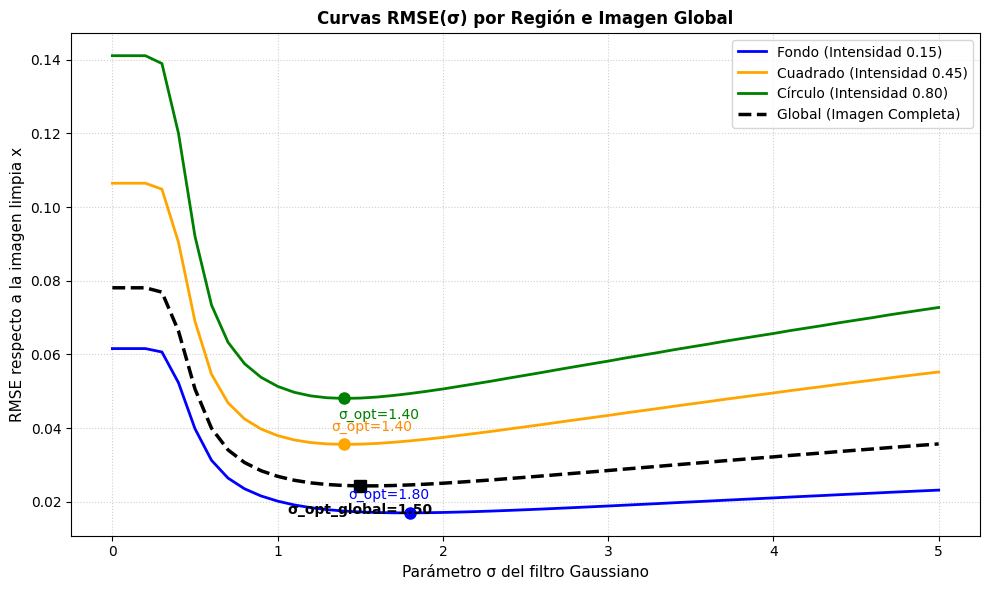

In [5]:
# Graficar RMSE vs sigma
plt.figure(figsize=(10, 6))
plt.plot(sigmas, rmse_fondo, 'b-', label='Fondo (Intensidad 0.15)', linewidth=2)
plt.plot(sigmas, rmse_cuadrado, 'orange', label='Cuadrado (Intensidad 0.45)', linewidth=2)
plt.plot(sigmas, rmse_circulo, 'g-', label='Círculo (Intensidad 0.80)', linewidth=2)
plt.plot(sigmas, rmse_global, 'k--', label='Global (Imagen Completa)', linewidth=2.5)

# marcar los puntos mínimos
plt.plot(sigma_min_fondo, rmse_fondo[idx_min_fondo], 'bo', markersize=8)
plt.plot(sigma_min_cuadrado, rmse_cuadrado[idx_min_cuadrado], 'o', color='orange', markersize=8)
plt.plot(sigma_min_circulo, rmse_circulo[idx_min_circulo], 'go', markersize=8)
plt.plot(sigma_min_global, rmse_global[idx_min_global], 'ks', markersize=8)

plt.annotate(f'σ_opt={sigma_min_fondo:.2f}', (sigma_min_fondo, rmse_fondo[idx_min_fondo]),
             textcoords="offset points", xytext=(-15, 10), ha='center', color='blue')
plt.annotate(f'σ_opt={sigma_min_cuadrado:.2f}', (sigma_min_cuadrado, rmse_cuadrado[idx_min_cuadrado]),
             textcoords="offset points", xytext=(20, 10), ha='center', color='darkorange')
plt.annotate(f'σ_opt={sigma_min_circulo:.2f}', (sigma_min_circulo, rmse_circulo[idx_min_circulo]),
             textcoords="offset points", xytext=(25, -15), ha='center', color='green')
plt.annotate(f'σ_opt_global={sigma_min_global:.2f}', (sigma_min_global, rmse_global[idx_min_global]),
             textcoords="offset points", xytext=(0, -20), ha='center', color='black', fontweight='bold')

plt.xlabel('Parámetro σ del filtro Gaussiano', fontsize=11)
plt.ylabel('RMSE respecto a la imagen limpia x', fontsize=11)
plt.title('Curvas RMSE(σ) por Región e Imagen Global', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p1', 'curvas_rmse.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 3. Tabla resumen

In [6]:
print("="*75)
print(f"{'Región / Nivel':<25} | {'σ óptimo':<12} | {'RMSE Mínimo':<12} | {'RMSE Sin Filtro':<12}")
print("="*75)
print(f"{'Fondo (0.15)':<25} | {sigma_min_fondo:<12.2f} | {rmse_fondo[idx_min_fondo]:<12.5f} | {rmse_fondo[0]:<12.5f}")
print(f"{'Cuadrado (0.45)':<25} | {sigma_min_cuadrado:<12.2f} | {rmse_cuadrado[idx_min_cuadrado]:<12.5f} | {rmse_cuadrado[0]:<12.5f}")
print(f"{'Círculo (0.80)':<25} | {sigma_min_circulo:<12.2f} | {rmse_circulo[idx_min_circulo]:<12.5f} | {rmse_circulo[0]:<12.5f}")
print(f"{'Global (Imagen Total)':<25} | {sigma_min_global:<12.2f} | {rmse_global[idx_min_global]:<12.5f} | {rmse_global[0]:<12.5f}")
print("="*75)

Región / Nivel            | σ óptimo     | RMSE Mínimo  | RMSE Sin Filtro
Fondo (0.15)              | 1.80         | 0.01704      | 0.06160     
Cuadrado (0.45)           | 1.40         | 0.03562      | 0.10645     
Círculo (0.80)            | 1.40         | 0.04809      | 0.14104     
Global (Imagen Total)     | 1.50         | 0.02437      | 0.07809     


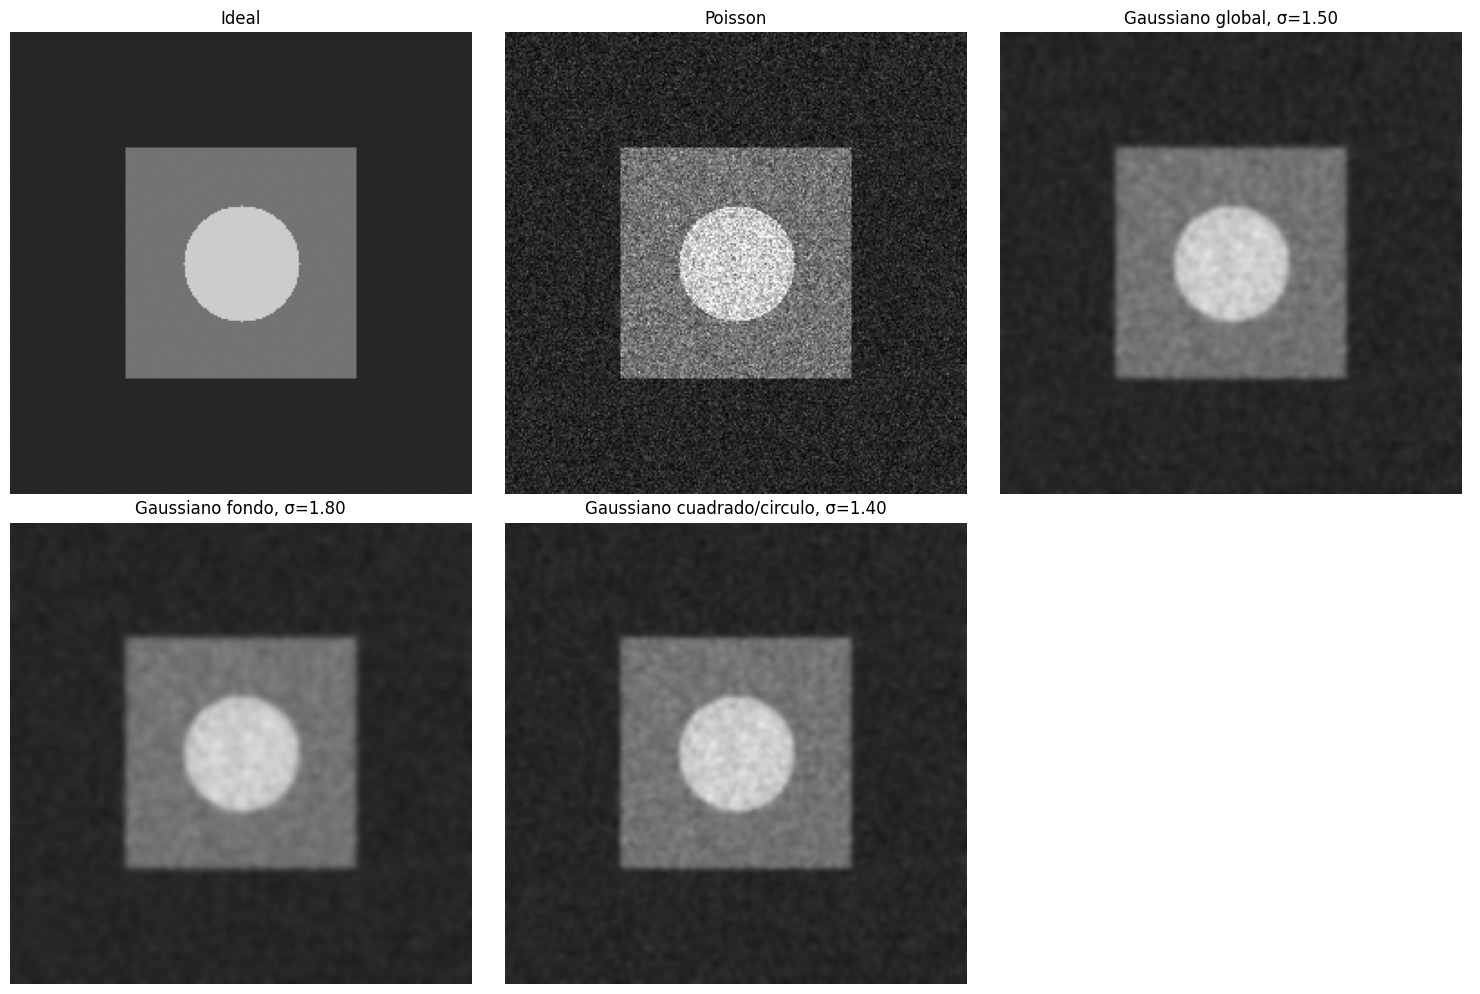

In [7]:
# Aplicación del filtro gaussiano con los sigma óptimos para cada región y global
imagen_global = filtro_gaussiano(y, sigma_min_global)
imagen_fondo = filtro_gaussiano(y, sigma_min_fondo)
imagen_cuad_cir = filtro_gaussiano(y, sigma_min_cuadrado)

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(x, cmap="gray", vmin=0, vmax=1)
ax[0, 0].set_title("Ideal")

ax[0, 1].imshow(y,cmap="gray",vmin=0,vmax=1)
ax[0, 1].set_title("Poisson")

ax[0, 2].imshow(imagen_global,cmap="gray",vmin=0,vmax=1)
ax[0, 2].set_title(f"Gaussiano global, σ={sigma_min_global:.2f}")

ax[1, 0].imshow(imagen_fondo,cmap="gray",vmin=0,vmax=1)
ax[1, 0].set_title(f"Gaussiano fondo, σ={sigma_min_fondo:.2f}")

ax[1, 1].imshow(imagen_cuad_cir,cmap="gray",vmin=0,vmax=1)
ax[1, 1].set_title(f"Gaussiano cuadrado/circulo, σ={sigma_min_cuadrado:.2f}")

for a in ax.flatten():
    a.axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p1', 'filtro_gaussiano_optimo_region.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 4. Análisis Curvas RMSE

- Se observa que el filtro gaussiano reduce considerablemente el RMSE en todas las regiones respecto al caso sin filtrar. El RMSE Global disminuye de 0.07809 a 0.02437 (-68.79%) con $\sigma$ óptimo de 1.50.

- Efecto del ruido Poisson: Los RMSE sin filtrado aumentan según la intensidad de la región (0.062 para el fondo, 0.106 para el cuadrado y 0.141 para el círculo). Consistente con ruido Poisson, cuya varianza depende de la intensidad y por lo tanto las regiones con mayor intensidad tienen mayor variabilidad al ruido

- 

- **$\sigma$ óptimo:** El $\sigma$ que minimiza el error es distinto en cada región (fondo)  
- **Variabilidad del ruido Poisson:** Las regiones de mayor intensidad (círculo 0.80) presentan mayor varianza inicial (RMSE $\approx 0.141$ en $\sigma=0$) en comparación con el fondo 0.15 (RMSE $\approx 0.061$).
- **Trade-off de suavizado y bordes:** El fondo admite un filtro más ancho ($\sigma_{\text{opt}}=1.80$) por ser predominantemente plano, mientras que las estructuras internas se optimizan en $\sigma_{\text{opt}}=1.40$ para mitigar el error por difuminado de bordes (blurring).
- **Justificación adaptativa:** El óptimo global ($\sigma_{\text{opt}}=1.50$, RMSE $=0.02437$ ) representa un compromiso promedio, confirmando la necesidad de un enfoque adaptativo $\sigma(x,y)$ según la intensidad local.
Sin embargo, el σ óptimo no depende únicamente del nivel de ruido. Un aumento de σ también incrementa el suavizado a través de las fronteras entre regiones de distinta intensidad, generando un compromiso entre reducción del ruido y preservación de los bordes. Esto es especialmente relevante para el círculo, que se encuentra rodeado por el cuadrado. Por esta razón, el valor óptimo resulta de considerar simultáneamente la reducción del ruido y el error introducido por el suavizado de las fronteras.

### Análisis de resultados

Se observa que el RMSE disminuye considerablemente al aplicar el filtro Gaussiano, alcanzando un mínimo en cada región. El fondo presenta el óptimo en σ = 1.80, mientras que el cuadrado y el círculo lo presentan en σ = 1.40. El RMSE global alcanza su mínimo en σ = 1.50. Esto muestra que no existe un único σ óptimo para todas las regiones, debido al compromiso entre reducción del ruido y preservación de las fronteras.

**Análisis de las Curvas RMSE(σ):**
- **Variabilidad del ruido Poisson:** Las regiones de mayor intensidad (círculo 0.80) presentan mayor varianza inicial ($\text{RMSE} \approx 0.141$ en $\sigma=0$) en comparación con el fondo 0.15 ($\text{RMSE} \approx 0.061$).
- **Trade-off de suavizado y bordes:** El fondo admite un filtro más ancho ($\sigma_{\text{opt}}=1.80$) por ser predominantemente plano, mientras que las estructuras internas se optimizan en $\sigma_{\text{opt}}=1.40$ para mitigar el error por difuminado de bordes (*blurring*).
- **Justificación adaptativa:** El óptimo global ($\sigma_{\text{opt}}=1.50$, $\text{RMSE}=0.02437$) representa un compromiso promedio, confirmando la necesidad de un enfoque adaptativo $\sigma(x,y)$ según la intensidad local.

## 4) Regla $\sigma = F(\hat{\mu})$ adaptar ancho del gaussiano

DEMOSTRACIÓN PASO A PASO PARA 3 PÍXELES DE EJEMPLO:
• Región: Fondo (Intensidad Ideal 0.15) - Coordenada (10, 10):
  1. Valor Ruidoso y(x,y)           : 0.1500
  2. Intensidad Estimada μ̂(x,y)   : 0.1652
  3. Mapeo σ(x,y) = F(μ̂)       : 1.7797
  4. Valor Filtrado Adaptativo     : 0.1554

• Región: Cuadrado (Intensidad Ideal 0.45) - Coordenada (80, 80):
  1. Valor Ruidoso y(x,y)           : 0.3500
  2. Intensidad Estimada μ̂(x,y)   : 0.4695
  3. Mapeo σ(x,y) = F(μ̂)       : 1.4000
  4. Valor Filtrado Adaptativo     : 0.4720

• Región: Círculo (Intensidad Ideal 0.80) - Coordenada (128, 128):
  1. Valor Ruidoso y(x,y)           : 0.7500
  2. Intensidad Estimada μ̂(x,y)   : 0.7670
  3. Mapeo σ(x,y) = F(μ̂)       : 1.4000
  4. Valor Filtrado Adaptativo     : 0.7778

Región               | Mejor Global (σ=1.50)  | Adaptativo σ(x,y)     
Fondo (0.15)         | 0.01729                | 0.01693               
Cuadrado (0.45)      | 0.03568                | 0.03579               
Círculo (0.80)

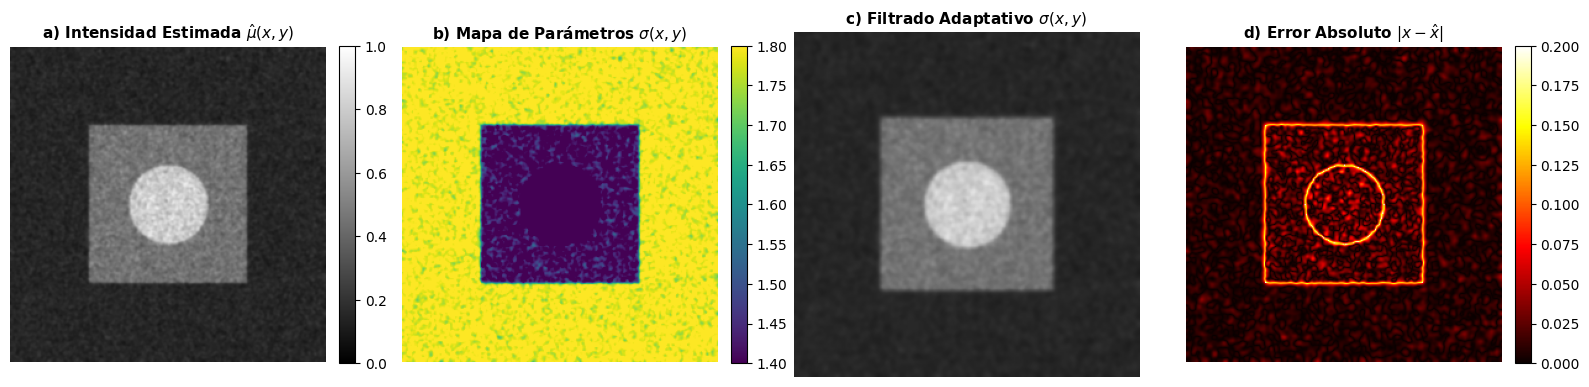

In [ ]:
#  Estimacion mu(x,y) con filtrado gaussiano con sigma auxiliar
sigma_aux = 1.0 # atenuar ruido sin destruir bordes
mu_hat = filtro_gaussiano(y, sigma_aux)

# Regla de Mapeo F(\hat{\mu}) -> \sigma(x,y) basada en óptimos medidos con interpolación
intensidades_ref = np.array([0.15, 0.45, 0.80])
sigmas_opt_ref = np.array([1.80, 1.40, 1.40])
mapa_sigma = funcion_mapeo_sigma(mu_hat, intensidades_ref, sigmas_opt_ref)

# 3. Implementación del Filtrado Adaptativo mediante Banco de Filtros


# Ejecución del filtrado adaptativo y filtrado global de referencia (\sigma = 1.50)
y_adaptativo = filtrar_gaussiano_adaptativo(y, mapa_sigma)
y_mejor_global = filtro_gaussiano(y, 1.50)

# 4. Cálculo de Métricas RMSE Comparativas
rmse_adapt_tot = rmse(x, y_adaptativo)
rmse_adapt_fon = rmse(x, y_adaptativo, mask_fondo)
rmse_adapt_cua = rmse(x, y_adaptativo, mask_cuadrado)
rmse_adapt_cir = rmse(x, y_adaptativo, mask_circulo)

rmse_glob_fon = rmse(x, y_mejor_global, mask_fondo)
rmse_glob_cua = rmse(x, y_mejor_global, mask_cuadrado)
rmse_glob_cir = rmse(x, y_mejor_global, mask_circulo)
rmse_glob_tot = rmse(x, y_mejor_global)

# 5. Demostración paso a paso para 3 píxeles de ejemplo (solicitado en la pauta)
pixeles_ejemplo = [
    ("Fondo (Intensidad Ideal 0.15)", (10, 10)),
    ("Cuadrado (Intensidad Ideal 0.45)", (80, 80)),
    ("Círculo (Intensidad Ideal 0.80)", (128, 128))
]

print("="*75)
print("DEMOSTRACIÓN PASO A PASO PARA 3 PÍXELES DE EJEMPLO:")
print("="*75)
for nombre, (r, c) in pixeles_ejemplo:
    val_y = y[r, c]
    val_mu = mu_hat[r, c]
    val_sigma = mapa_sigma[r, c]
    val_out = y_adaptativo[r, c]
    print(f"• Región: {nombre} - Coordenada ({r}, {c}):")
    print(f"  1. Valor Ruidoso y(x,y)           : {val_y:.4f}")
    print(f"  2. Intensidad Estimada \u03bc\u0302(x,y)   : {val_mu:.4f}")
    print(f"  3. Mapeo \u03c3(x,y) = F(\u03bc\u0302)       : {val_sigma:.4f}")
    print(f"  4. Valor Filtrado Adaptativo     : {val_out:.4f}\n")

# Tabla de Comparación Cuantitativa
print("="*75)
print(f"{'Región':<20} | {'Mejor Global (\u03c3=1.50)':<22} | {'Adaptativo \u03c3(x,y)':<22}")
print("="*75)
print(f"{'Fondo (0.15)':<20} | {rmse_glob_fon:<22.5f} | {rmse_adapt_fon:<22.5f}")
print(f"{'Cuadrado (0.45)':<20} | {rmse_glob_cua:<22.5f} | {rmse_adapt_cua:<22.5f}")
print(f"{'Círculo (0.80)':<20} | {rmse_glob_cir:<22.5f} | {rmse_adapt_cir:<22.5f}")
print("-" * 75)
print(f"{'GLOBAL (Total)':<20} | {rmse_glob_tot:<22.5f} | {rmse_adapt_tot:<22.5f}")
print("="*75)

# 6. Despliegue de Mapas Visuales
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

im0 = axes[0].imshow(mu_hat, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(r'a) Intensidad Estimada $\hat{\mu}(x,y)$', fontsize=11, fontweight='bold')
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(mapa_sigma, cmap='viridis')
axes[1].set_title(r'b) Mapa de Parámetros $\sigma(x,y)$', fontsize=11, fontweight='bold')
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(y_adaptativo, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(r'c) Filtrado Adaptativo $\sigma(x,y)$', fontsize=11, fontweight='bold')
axes[2].axis('off')

im3 = axes[3].imshow(np.abs(x - y_adaptativo), cmap='hot', vmin=0, vmax=0.2)
axes[3].set_title(r'd) Error Absoluto $|x - \hat{x}|$', fontsize=11, fontweight='bold')
axes[3].axis('off')
fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



**Análisis del Filtrado Espacialmente Adaptativo:**
- **Procesamiento por píxel:** La estimación auxiliar $\hat{\mu}(x,y)$ atenúa la variabilidad impulsiva del ruido Poisson, permitiendo construir un mapa espacial $\sigma(x,y)$ continuo. En el fondo se asigna el nivel máximo de suavizado ($\sigma=1.80$), mientras que en las estructuras internas el parámetro se reduce a $\sigma=1.40$.
- **Mejora cuantitativa:** El filtro adaptativo reduce el RMSE en el fondo de $0.01729$ (obtenido con el mejor global $\sigma=1.50$) a $0.01693$, logrando una menor métrica de error global ($\text{RMSE}=0.02420$ vs $0.02437$).
- **Transiciones de borde:** Cerca de las fronteras entre regiones, $\hat{\mu}(x,y)$ genera una zona de transición suave en $\sigma(x,y)$ que evita discontinuidades abruptas en la imagen filtrada.